In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:80% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:10pt;}
div.output {font-size:10pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:10pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:10pt;padding:2px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="green">ch10. N차원 배열 다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
- [NUMPY](https://numpy.org)
- [numpy API Docs](https://numpy.org/doc/stable/reference/index.html)

# 1절. 넘파이 패키지

In [3]:
import numpy as np
np.__version__ # tensorflow == 2.10과 맞는 numpy 버전

'1.23.5'

In [5]:
# np.arange(from, stop, by) : form부터 stop앞까지 by씩 증가하는 1차원 정수 배열
a = np.arange(15)
print(a.shape) # 15열짜리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1 배열속성


In [21]:
from numpy import arange
a = arange(15, 
           # dtpye=np.int32
          ).reshape(3, 5) # 3행 5열짜리로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [13]:
# a 변수의 타입을 물어본 것
type(a)

numpy.ndarray

In [14]:
# a 배열의 요소들의 type
a.dtype 

dtype('int32')

In [16]:
a.dtype.name

'int32'

In [17]:
a.itemsize # 한 요소(item)의 bytesize

4

In [18]:
a.ndim # 축수(차원수)

2

In [19]:
a.size # 배열 요소의 갯수

15

In [15]:
# 배열 구조(1차원 15열)
a.shape

(3, 5)

In [24]:
print('shape 조정전 a:\n', a)
a.shape = (5,3)
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


## 1.2 배열 타입 변경


In [25]:
# 배열 요소의 타입변경(X)
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [26]:
a.size # 요소갯수

12

In [27]:
a.dtype # 저장되어 있는 것을 32bit씩 읽겠다.

dtype('int32')

In [28]:
a.itemsize # 요소의 byte수

4

In [29]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [30]:
a.itemsize 

8

### 배열 요소의 타입변경


In [31]:
a = arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [32]:
a.astype(np.int64) # 출력 0 -> a가 바뀌지 않음 / 출력 x -> a 바뀜.

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [35]:
a.dtype

dtype('int32')

In [36]:
a.itemsize

4

In [37]:
a.ravel() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [38]:
a.flatten() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.3 배열 저장
- pkl(객체저장, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [68]:
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [69]:
%%time
import time
start = time.time() # 1970.01.01부터 지금까지의 초수
import pickle
with open('Data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)
end = time.time()
print('실행 시간 :', (end-start))

실행 시간 : 0.001444101333618164
CPU times: total: 0 ns
Wall time: 1.44 ms


In [70]:
%%time
with open('Data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f)

CPU times: total: 15.6 ms
Wall time: 36.9 ms


In [71]:
# a ==(파일 저장)==> 피클파일(269B) ==(load)==> loaded_a
loaded_a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [72]:
%%time
np.save('Data/ch11.npy', a) # 넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 2 ms


In [73]:
%%time
loaded_a2 = np.load('Data/ch11.npy')

CPU times: total: 15.6 ms
Wall time: 15.9 ms


In [74]:
# a ==(저장)==> npy(248B) ==(load)==> loaded_a2
loaded_a2

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

# 2절. 넘파이 배열 

- array() 함수를 이용한 다른 파이썬 데이터 구조(list, tup)를 배열변환
- 특정값을 갖는 배열 생성 함수 : arange, ones, zeros, full, empty .....
- 랜덤값을 갖는 배열 생성함수...
- [넘파이 함수들](https://numpy.org/doc/stable/reference/index.html)

## 2.1 array()함수로 넘파이 배열 만들기
- array(obj, dtype=np.type, copy=T/F)
- array(obj, dtype='type', copy=T/F) \
type 예 : int16, int32, float16, float32, float64....

In [57]:
a = np.array([2, 14, 6]
            # dtype=np.int16
            )# 정수의 기본 타입은 int32 / 실수의 기본타입은 float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [58]:
a[0], a[1], a[2]

(2, 14, 6)

In [59]:
for item in a:
    print(item, end='\t')

2	14	6	

In [61]:
b = np.array([[1.5, 2.3],  # 동일 자료형의 집합으로 배열 생성: 정수>실수>문자
            [4, 5]])       # 실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [76]:
b.dtype

dtype('float64')

In [78]:
l = [[1.5, 2.3], [4, 5]]
l[0][1]

2.3

In [63]:
b[0,1] # 2차원 [axis0=행, axis0=열] cf. 1차원[axis0=열]

2.3

In [75]:
a = np.array([[1.5, 2.3], 
              [4, 5]], dtype=np.float32)
a.dtype

dtype('float32')

In [81]:
# a의 배열 구조 변경
a.shape = (2, 2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [82]:
# a의 dtype(요소의 타입) 변경
# a.dtype = np.float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [84]:
l = [[1.5, 2.3], 
              [4, 5]]
for row in l :
    for item in row:
        print(item, end=' ')
        print()

1.5 
2.3 
4 
5 


In [86]:
for i, row in enumerate(a) :
    for j, item in enumerate(row):
        # print(f"{i}행{j}열 : {a[i][j]}", end='\t')
        print(f"{i}행{j}열 : {a[i,j]}", end='\t') # float16은 소숫점이하가 불안정
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


### 인덱싱(Indexing)
 : 색인, 목차, 지표 (찾아보기) \
" 데이터가 일렬로 늘어서 있을 때, 각 데이터에 매겨진 '위치 번호(주소)'를 사용해 원하는 것만 콕 집어내는 작업"
- print(b[0,2])없는 인덱싱은 에러

In [87]:
print(b[0,0])
print()

1.5



### 슬라이싱
- from : stop :  \
  from부터 stop전까지 by씩 전진. 인덱싱은 음수
  
- 0~끝행, 1열부터 끝열까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)

In [88]:
b[0:, -1]

array([2.3, 5. ])

In [89]:
b[0, 1:3] # 0행, 1열부터 3열전까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([2.3])

#### ex1 ) 모든 행의 마지막 열만 추출
```
b = np.arrary([[1, 2, 3,]
               [6, 7, 8]])
```

In [90]:
b = np.array([[1, 2, 3],
              [6, 7, 8]])
b

array([[1, 2, 3],
       [6, 7, 8]])

In [99]:
b[:, -1]

array([3, 8])

#### ex2 ) 모든 행의 마지막 열을 제외한 부분 추출

In [98]:
b[0:2, 0:2]

array([[1, 2],
       [6, 7]])

In [103]:
# copy 사용
# 스칼라 변수
a = 10  #원본
b = a  #복제본
print("a={}, b={}, a주소={}, b주소{}".format(a, b, id(a), id(b)))
b = -1
print("a={}, b={}, a주소={}, b주소{}".format(a, b, id(a), id(b)))

a=10, b=10, a주소=2570225975824, b주소2570225975824
a=10, b=-1, a주소=2570225975824, b주소2570225975472


#### # numpy 배열

In [111]:
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # dtype="int16"==dtype.int16  / dtype=np.uint16_음수가 안나온다나?
d = np.array(c, copy=False)# d = c # 할당하기
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2570385650480 2570385650480
c=
[[9 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2570385650480 2570385650480


In [112]:
c = np.array([[1, 2], [3, 4]], dtype=np.int8)
d = np.array(c, copy=True) # d = c.copy()와 동일 # 깊은 복사
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2570385638768 2570385645488
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2570385638768 2570385645488


#### # copy = False해도 깊은 복사가 되는 경우
- dtype이 바뀌면 자동으로 깊은 복사가 됨.

In [113]:
c = np.array([[1, 2], [3, 4]], dtype=np.int8)
d = np.array(c, copy=False, dtype=np.int32)
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2570386457296 2570386457200
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2570386457296 2570386457200


## 2.2 기본값이 있는 배열 만들기

- np.zeros( tup [, dtype] ) : 요소들이 다 0.0
- np.ones( tup [, dtype] ) : 요소들이 다 1.0
- np.full( tup, 기본값 ) : 요소들이 다 두 번째 매개변수인 기본값
- np.empty( tup ) : 초기 내용을 임의의 값인 배열(메모리 상태에 따라 달라짐

**※위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64. dtype속성을 따로 지정할 수 있음**

#### # zeros

In [148]:
np.zeros((3,5)) # 3행 5열짜리 2차원 Float64 배열(요소들은 다 0)
np.zeros((5,)) # 5열짜리 1차원 float64 배열(요소들은 다 0)
np.zeros(5) # 5열짜리 1차원 float64 배열 (요소들은 다 0)

array([0., 0., 0., 0., 0.])

In [151]:
x = np.zeros( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


####  # ones

In [152]:
np.ones((3,5)) # 3행 5열짜리 2차원 Float64 배열(요소들은 다 1)
np.ones((5,)) # 5열짜리 1차원 float64 배열(요소들은 다 1)
np.ones(5) # 5열짜리 1차원 float64 배열 (요소들은 다 1)

array([1., 1., 1., 1., 1.])

In [153]:
x = np.ones( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


####  # full

In [155]:
x = np.full( (2, 5), 255 )
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


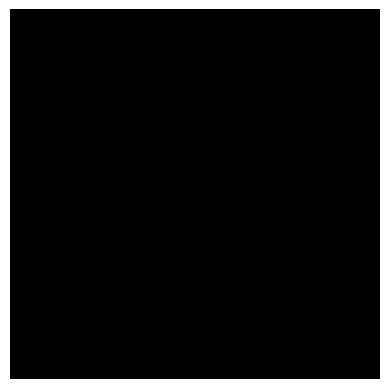

In [170]:
# 이미지 만들기
import matplotlib.pyplot as plt
img = np.full( (28, 28), 255, dtype=np.uint8) # 하얀색
img = np.full( (28, 28), 200, dtype=np.uint8) #회색
img = np.zeros( (28, 28), dtype=np.uint8) # 검정색
# plt.figure(figsize)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')
plt.show()

In [174]:
import numpy as np
np.empty((3,2))

array([[  0.,   0.],
       [  0., 480.],
       [640.,   0.]])

##  2.3 랜더값을 갖는 배열 만들기

- np.random.random(tup) : 0부터 1미만의 균등분포를 갖은 tuo사이즈 랜덤값
- np.random.unifom(low=0, high=1.0, sizw=tup): low부터 high미만까지 균등분포를 갖는 랜덤값

- np.random.normal(loc=0.0, scale-1.0, size=tup) : 평균loc, 표준편차scale을 갖는 정규분포 랜더값 ★가장 많이 사용되는 식★

```
표준편차(기초통계)


```

- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n) : 표준정규분포(평균0, 표준편차가 1인 정규분포)의 1차원 난수 배열 발생(난수 n개)


- np.random.randint(n) : 0부터 n미만의 정수 난수 1개 발생 == random.randint(0, n-1)
- np.random.randint(from, to) : from 부터 to미만의 정수 난수 1개 발생 == random.randint(from, to-1)

In [175]:
np.random.random((2,3))

array([[0.0028145 , 0.27297698, 0.23767735],
       [0.31396309, 0.13008799, 0.91678204]])

In [177]:
np.random.rand(10000)

array([0.80690307, 0.83078561, 0.13799112, ..., 0.28957734, 0.42194557,
       0.58080443])

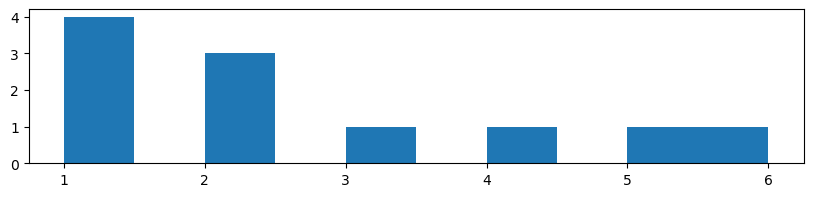

In [183]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = [1, 1, 1, 2, 2, 1, 2, 3, 4, 5, 6]
plt.hist(x, bins=10)
plt.show()

###  # 균등분포

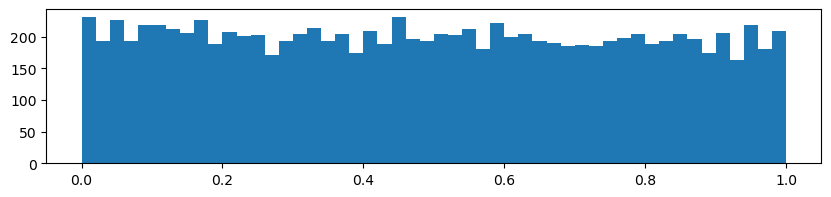

In [195]:
# 균등분포
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.random(100000)
# print(x)
# x = np.random.uniform(1, 10, 10)
x = np.random.rand(10000)
plt.hist(x, bins=50)
plt.show()

### # 정규분포

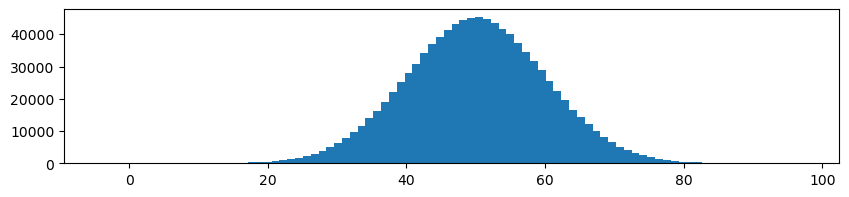

In [202]:
# 정규분포
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(50, 10, 1000000)
plt.hist(x, bins=90)
plt.show()

###  # 표준정규분포

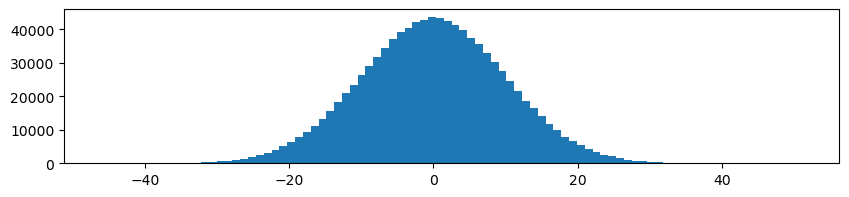

In [201]:
# 표준정규분포 1
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(0, 10, 1000000)
plt.hist(x, bins=90)
plt.show()

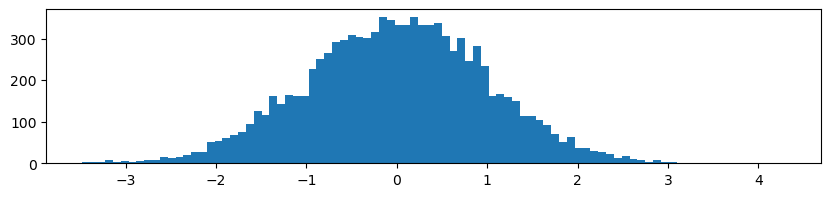

In [205]:
# 표준정규분포 2
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.randn(10000)
plt.hist(x, bins=90)
plt.show()

# 3절. 배열 합치기 / 분할하기

# 4절 복사와 뷰

## 4.1 할당

In [114]:
# 스칼라 변수
a = 10
b = a
print('a와 b주소 :', id(a), id(b))
b = 99
print('수정 후 a와 b주소 :', id(a), id(b))
print('수정 후 a와 b 데이터 :', a, b)

a와 b주소 : 2570225975824 2570225975824
수정 후 a와 b주소 : 2570225975824 2570225978672
수정 후 a와 b 데이터 : 10 99


In [115]:
# 배열
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [116]:
b = a
# b = np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 2570385638288)

In [117]:
b.shape, type(b), b.ndim, id(b)

((12,), numpy.ndarray, 1, 2570385638288)

In [118]:
a is b

True

In [119]:
a == b # 요소별 비교

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [120]:
np.all(a==b) #np.all() array 배열 안의 모든 값이 True인지 여부

True

In [121]:
b.shape = (3, 4)

In [122]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 2570385638288)

In [123]:
a.shape

(3, 4)

## 4.2 뷰(View): 얕은 복사

In [124]:
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [126]:
c = a.view() # 얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [127]:
id(a), id(c)

(2570385641264, 2570382562512)

In [128]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [129]:
a is c

False

In [131]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [132]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [133]:
# 배열 복사본 c의 특정 요소만 변경
c[1, ::2] = -99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [139]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
             [88, 71, 77, 77],
             [99, 99, 99, 99]])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [136]:
X = a[:, :-1]
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [137]:
X[0:2, -1] = 1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [88, 71,  1],
       [99, 99, -1]])

In [138]:
a

array([[99, 88,  1, 85],
       [88, 71,  1, 77],
       [99, 99, -1, 99]])

## 4.3 깊은 복사

In [140]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
             [88, 71, 77, 77],
             [99, 99, 99, 99]])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [ ]:
# 독립 변수 뽑기
# X = a[:, :-1] 얕은 복사(view 생성)
X = a[:, :-1].copy() # 깊은 복사
X = np.array(a[:, :-1], copy=True) #깊은 복사

In [141]:
X[:, 0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1, -1]])

In [142]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])